### Vamos a convertir algunas columnas a otro tipo de dato más correcto (y eliminamos las dos columnas de machine learning)

In [1]:
#%pip install matplotlib scipy seaborn
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns

pd.set_option('display.max_columns', None)

df_clean = pd.read_csv('../data/raw/BankChurners.csv')
df_clean = df_clean.iloc[:, :-2]

In [2]:
# 1. Attrition_Flag -> binario
df_clean['Attrition_Flag'] = df_clean['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

# 2. Gender -> binario
df_clean['Gender'] = df_clean['Gender'].map({
    'M': 0,
    'F': 1
})

In [3]:
df_clean[['Attrition_Flag', 'Gender']].dtypes

Attrition_Flag    int64
Gender            int64
dtype: object

### Comprobamos la asimetría de cada variable númerica para decidir el método de detección de outliers (sin tener en cuenta CLIENTNUM, Attrition_Flag ni Gender)

In [4]:
df_clean.select_dtypes(include=['int64', 'float64']).skew().sort_values(ascending=False)

Total_Ct_Chng_Q4_Q1         2.064031
Total_Trans_Amt             2.041003
Attrition_Flag              1.848449
Total_Amt_Chng_Q4_Q1        1.732063
Credit_Limit                1.666726
Avg_Open_To_Buy             1.661697
CLIENTNUM                   0.995601
Avg_Utilization_Ratio       0.718008
Months_Inactive_12_mon      0.633061
Total_Trans_Ct              0.153673
Contacts_Count_12_mon       0.011006
Dependent_count            -0.020826
Customer_Age               -0.033605
Months_on_book             -0.106565
Gender                     -0.116537
Total_Revolving_Bal        -0.148837
Total_Relationship_Count   -0.162452
dtype: float64

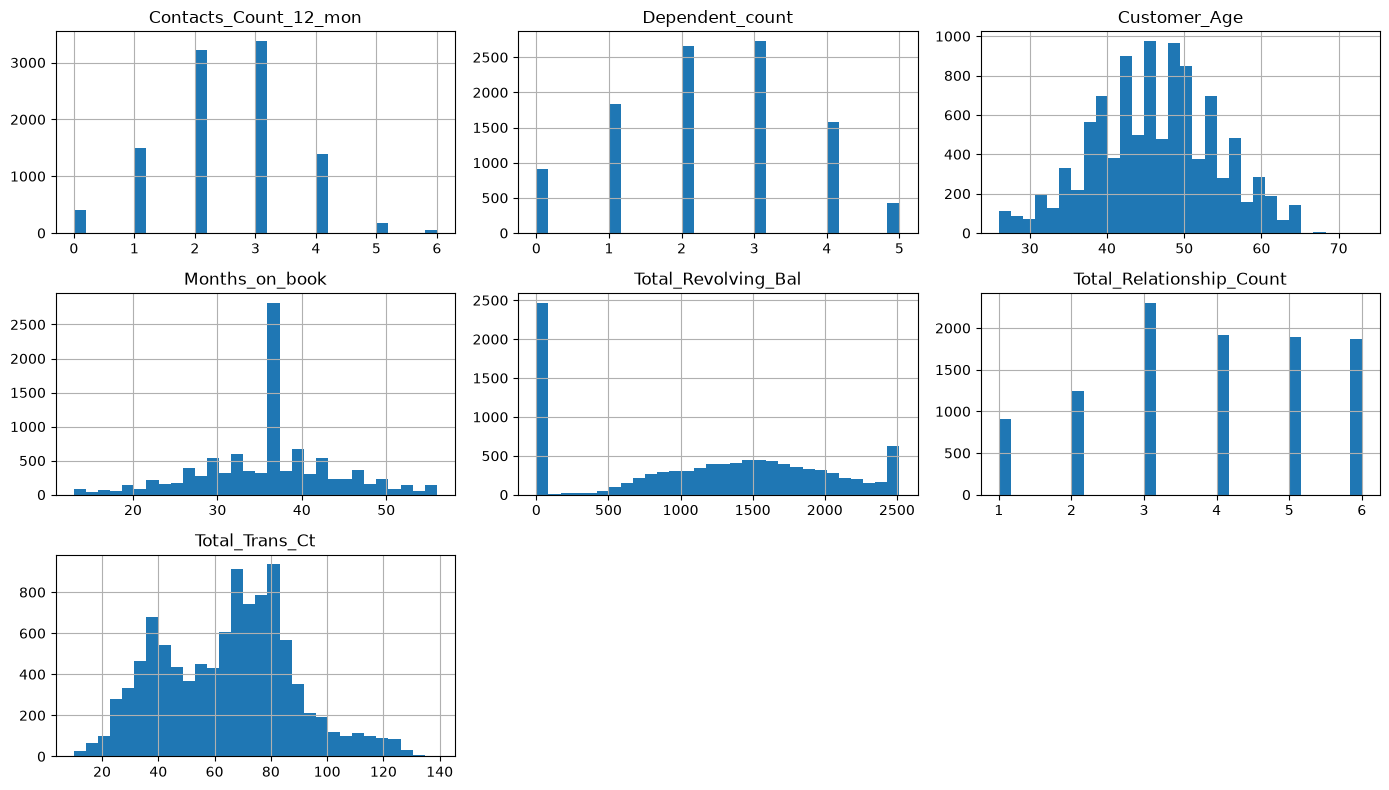

In [5]:
revisables = ['Contacts_Count_12_mon', 'Dependent_count', 'Customer_Age',
              'Months_on_book', 'Total_Revolving_Bal',
              'Total_Relationship_Count', 'Total_Trans_Ct']

df_clean[revisables].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

### De las 7 variables, solo Customer_Age justifica Z-score (unimodal, simétrica, sin picos secundarios). El resto debería tratarse con IQR, y Months_on_book y Total_Revolving_Bal merecen además una revisión adicional antes de hablar de "outliers" propiamente dichos (uno por posible relleno sintético de datos desconocidos, otro por ser un segmento de cliente legítimo).

### Vamos a comprobar la magnitud del pico para Months_on_book

In [6]:
df_clean['Months_on_book'].value_counts().head(5)

Months_on_book
36    2463
37     358
34     353
38     347
39     341
Name: count, dtype: int64

In [7]:
(df_clean['Months_on_book'] == 36).mean() * 100

np.float64(24.32112175372766)

### En principio el porcentaje es desproporcionado con respecto a los valores vecinos (35, 37)

### Vamos a comparar el perfil de esos clientes contra el resto

In [8]:
df_clean.groupby(df_clean['Months_on_book'] == 36)[['Customer_Age', 'Total_Relationship_Count', 'Attrition_Flag']].mean()

,Customer_Age,Total_Relationship_Count,Attrition_Flag
Months_on_book,,,
False,46.380611,3.822286,0.156185
True,46.155907,3.782379,0.174584


### Ya que la media sola no es suficiente (dos grupos pueden tener la misma media y aun así uno tener mucha más dispersión que el otro), vamos a comparar también la desviación estándar:

In [9]:
df_clean.groupby(df_clean['Months_on_book'] == 36)['Customer_Age'].std()

Months_on_book
False    8.143922
True     7.606811
Name: Customer_Age, dtype: float64

### Debido a que el grupo de 36 meses tiene una tasa de 'churn' algo mayor para Attrition_flag (17.46% vs 15.62%), una diferencia de más o menos 1.8 puntos porcentuales, (es una diferencia pequeña pero no despreciable) vamos a ver si es estadísticamente significativa:

In [10]:
tabla = pd.crosstab(df_clean['Months_on_book'] == 36, df_clean['Attrition_Flag'])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p:.4f}")

p-valor: 0.0330


### Y visualicemos también la dispersión real

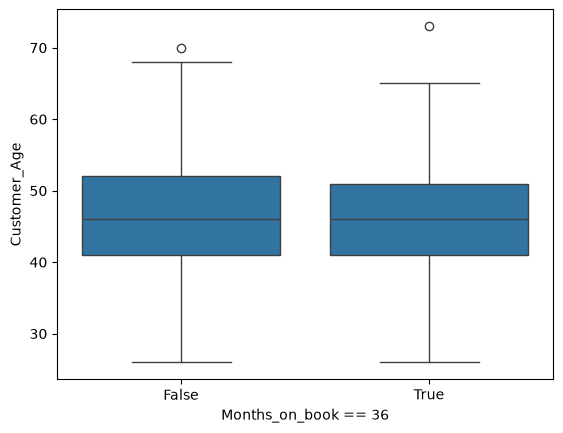

In [11]:
sns.boxplot(x=(df_clean['Months_on_book'] == 36), y=df_clean['Customer_Age'])
plt.xlabel('Months_on_book == 36')
plt.show()

### La hipótesis inicial (que 36 fuera un valor de relleno tipo "dato desconocido"para Months_on_book) queda descartada. El perfil demográfico (edad) es indistinguible entre ambos grupos, lo cual no es compatible con un placeholder que normalmente afectaría a un segmento concreto de clientes (nuevos, migrados, con datos incompletos).

### Ahora calculamos la magnitud del pico para Total_Revolving_Bal

In [12]:
n_cero = (df_clean['Total_Revolving_Bal'] == 0).sum()
pct_cero = (df_clean['Total_Revolving_Bal'] == 0).mean() * 100

print(f"Clientes con saldo revolving = 0: {n_cero}")
print(f"Porcentaje del total: {pct_cero:.2f}%")

Clientes con saldo revolving = 0: 2470
Porcentaje del total: 24.39%


### Vamos a verificar que Avg_Utilization_Ratio = Total_Revolving_Bal / Credit_Limit para poder comprobar la coherencia entre Total_revolving_Bal y Avg_Utilization_Ratio

In [13]:
df_clean['utilizacion_calculada'] = df_clean['Total_Revolving_Bal'] / df_clean['Credit_Limit']

# Comparar contra la columna original
(df_clean['utilizacion_calculada'] - df_clean['Avg_Utilization_Ratio']).abs().describe()

count    10127.000000
mean         0.000188
std          0.000165
min          0.000000
25%          0.000004
50%          0.000167
75%          0.000333
max          0.000500
dtype: float64

### Debido a que la diferencia entre ambas columnas es prácticamente 0, confirmamos la fórmula. Eliminamos la columna creada para la comprobación (utilización_calculada) y verificamos la coherencia anteriormente descrita

In [14]:
df_clean.drop(columns=['utilizacion_calculada'], inplace=True)

df_clean[df_clean['Total_Revolving_Bal'] == 0]['Avg_Utilization_Ratio'].describe()

count    2470.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Avg_Utilization_Ratio, dtype: float64

### Ya que el saldo revolving es 0, la utilización es también 0 en todos los casos. No hay ningún error de datos, es simplemente un grupo de clientes que no generan deuda revolving.  La coherencia es perfecta (Avg_Utilization_Ratio = 0.0 en los 2470 casos, sin ninguna desviación). Esto demuestra matemáticamente que el saldo cero es internamente consistente con el resto de variables del dataset — no hay ningún indicio de error, inconsistencia o de generación de datos sintéticos.

### Pasamos ahora al cálculo de IQR sobre el conjunto de campos que aplican. Excluimos Total_Relationship_Count, Dependent_count, Contacts_Count_12_mon, Months_Inactive_12_mon ya que son variables discretas acotadas con pocos valores posibles.

In [15]:
def outliers_iqr(df, columna, k=1.5):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - k * IQR
    limite_superior = Q3 + k * IQR

    mask = (df[columna] < limite_inferior) | (df[columna] > limite_superior)

    return {
        'columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': mask.sum(),
        'pct_outliers': round(mask.mean() * 100, 2)
    }

columnas_iqr = [
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio', 'Credit_Limit', 'Months_on_book'
]

resultados_iqr = pd.DataFrame([outliers_iqr(df_clean, col) for col in columnas_iqr])
resultados_iqr

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Total_Revolving_Bal,359.000,1784.000,1425.000,-1778.500,3921.500,0,0.00
1,Avg_Open_To_Buy,1324.500,9859.000,8534.500,-11477.250,22660.750,963,9.51
2,Total_Amt_Chng_Q4_Q1,0.631,0.859,0.228,0.289,1.201,396,3.91
3,Total_Trans_Amt,2155.500,4741.000,2585.500,-1722.750,8619.250,896,8.85
4,Total_Trans_Ct,45.000,81.000,36.000,-9.000,135.000,2,0.02
5,Total_Ct_Chng_Q4_Q1,0.582,0.818,0.236,0.228,1.172,394,3.89
6,Avg_Utilization_Ratio,0.023,0.503,0.480,-0.697,1.223,0,0.00
7,Credit_Limit,2555.000,11067.500,8512.500,-10213.750,23836.250,984,9.72
8,Months_on_book,31.000,40.000,9.000,17.500,53.500,386,3.81


### Vamos a revisar las columnas Avg_Open_To_Buy, Total_Trans_Amt y Credit_Limit. Ya que son variables con asimetría alta y pueden generar sobre-detección en la cola derecha

In [16]:
df_clean[df_clean['Avg_Open_To_Buy'] > 22660.750]['Avg_Open_To_Buy'].describe()

count      963.000000
mean     30531.662513
std       3650.608893
min      22664.000000
25%      27709.000000
50%      32329.000000
75%      33256.500000
max      34516.000000
Name: Avg_Open_To_Buy, dtype: float64

In [17]:
df_clean[df_clean['Total_Trans_Amt'] > 8619.250]['Total_Trans_Amt'].describe()


count      896.000000
mean     13770.194196
std       2302.445950
min       8620.000000
25%      13309.750000
50%      14379.500000
75%      15196.000000
max      18484.000000
Name: Total_Trans_Amt, dtype: float64

In [18]:
df_clean[df_clean['Credit_Limit'] > 23836.25]['Credit_Limit'].describe()

count      984.000000
mean     31551.339431
std       3764.074111
min      23848.000000
25%      28284.500000
50%      34516.000000
75%      34516.000000
max      34516.000000
Name: Credit_Limit, dtype: float64

### Recalculamos las 3 variables con 3xIQR en vez de 1.5xIQR

In [19]:
column_sesg = ['Avg_Open_To_Buy', 'Total_Trans_Amt', 'Credit_Limit']

resultados_k3 = pd.DataFrame([outliers_iqr(df_clean, col, k=3) for col in column_sesg])
resultados_k3

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Avg_Open_To_Buy,1324.5,9859.0,8534.5,-24279.0,35462.5,0,0.00
1,Total_Trans_Amt,2155.5,4741.0,2585.5,-5601.0,12497.5,737,7.28
2,Credit_Limit,2555.0,11067.5,8512.5,-22982.5,36605.0,0,0.00


### Debido a que Total_Trans_Amt mantenga un grupo tan numeroso incluso con un criterio conservador sugiere que no es una cola larga residual, sino un segmento de tamaño considerable con comportamiento estructuralmente distinto. Dado que Total_Trans_Amt está altamente correlacionado con Total_Trans_Ct (más transacciones, lógicamente, suelen implicar más importe), es razonable sospechar que Total_Trans_Amt tenga la misma estructura bimodal, y que ese 7.28% no sean "outliers" sino el segundo grupo/pico de la distribución (clientes con uso muy intensivo de la tarjeta). Verificamos si la distribución muestra dos picos.

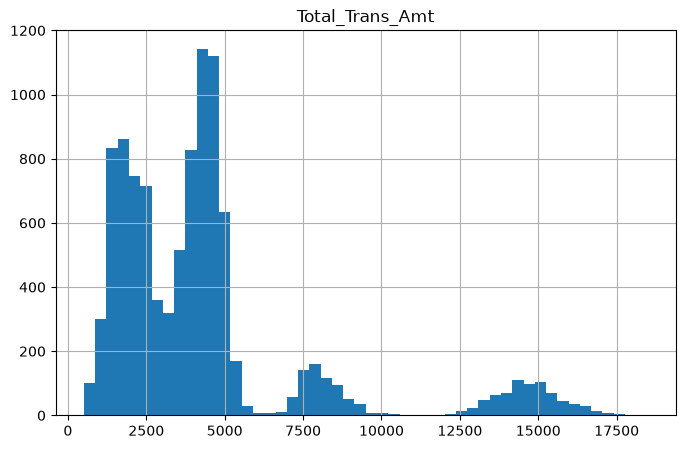

In [20]:
df_clean['Total_Trans_Amt'].hist(bins=50, figsize=(8,5))
plt.title('Total_Trans_Amt')
plt.show()

### Esto descarta definitivamente cualquier tratamiento de outliers (ni IQR estándar ni el ajustado con k=3) sobre esta columna. No hay forma estadística de tratar como "ruido" o "anomalía" a un grupo de cientos de clientes que ocupa su propio rango bien definido y separado por huecos reales en los datos. Eso no es una cola larga, es segmentación de comportamiento real

### Vamos a revisar ahora las columnas Total_Amt_Chng_Q4_Q1 y Total_Ct_Chng_Q4_Q1. Y comenzamos con la visualización de la distribución de cada ratio

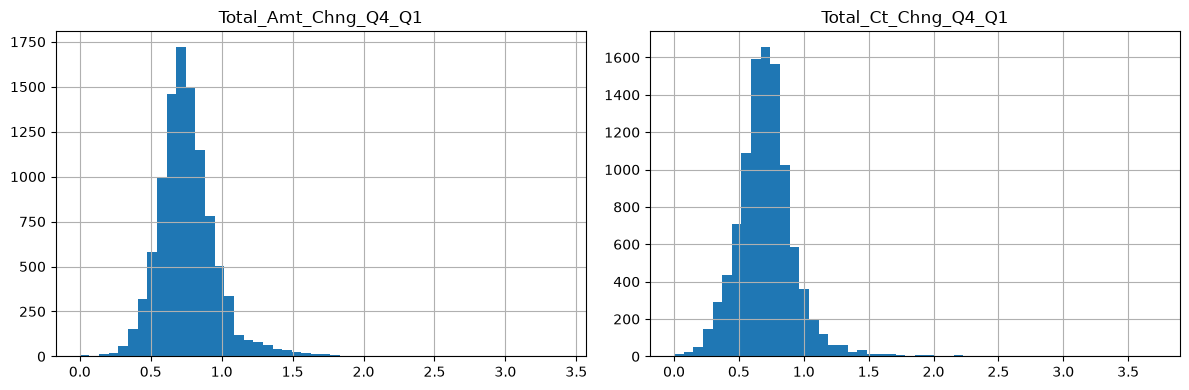

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean['Total_Amt_Chng_Q4_Q1'].hist(bins=50, ax=axes[0])
axes[0].set_title('Total_Amt_Chng_Q4_Q1')
df_clean['Total_Ct_Chng_Q4_Q1'].hist(bins=50, ax=axes[1])
axes[1].set_title('Total_Ct_Chng_Q4_Q1')
plt.tight_layout()
plt.show()

### No hay bimodalidad (a diferencia de Total_Revolving_Bal o Total_Trans_Amt), así que aquí no esperamos encontrar un "segmento oculto". Lo que vemos en la cola derecha son más bien casos individuales extremos, no un grupo estructural.

### Inspeccionamos los valores extremos

In [22]:
df_clean['Total_Amt_Chng_Q4_Q1'].describe()

count    10127.000000
mean         0.759941
std          0.219207
min          0.000000
25%          0.631000
50%          0.736000
75%          0.859000
max          3.397000
Name: Total_Amt_Chng_Q4_Q1, dtype: float64

In [23]:
df_clean['Total_Ct_Chng_Q4_Q1'].describe()

count    10127.000000
mean         0.712222
std          0.238086
min          0.000000
25%          0.582000
50%          0.702000
75%          0.818000
max          3.714000
Name: Total_Ct_Chng_Q4_Q1, dtype: float64

### El patrón es coherente con lo visto en el histograma (un núcleo muy compacto y homogéneo, con una cola derecha de casos genuinamente extremos pero relativamente pocos)

### Comprobamos si el valor 0 está sobrerepresentado. Si hay una concentración anómala en 0 podría tratarse de clientes que cerraron actividad en Q4 (dato real) o de un valor de relleno cuando la división Q4/Q1 no era calculable. Hay que distinguir ambos casos.

In [24]:
# Total_Amt_Chng_Q4_Q1 -> referencia: Total_Trans_Amt
df_clean.nsmallest(10, 'Total_Amt_Chng_Q4_Q1')[['Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt']]

,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt
3596,0.000,1152
4417,0.000,1447
4701,0.000,1246
7207,0.000,1201
7998,0.000,1339
7165,0.010,1507
4184,0.018,1097
7761,0.046,1554
5161,0.061,1533
6484,0.061,1628


In [25]:
df_clean.nlargest(10, 'Total_Amt_Chng_Q4_Q1')[['Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt']]

,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt
12,3.397,1539
8,3.355,1350
773,2.675,1731
2,2.594,1887
219,2.368,1546
47,2.357,1719
46,2.316,1741
658,2.282,1848
58,2.275,1359
466,2.271,1606


In [26]:
# Total_Ct_Chng_Q4_Q1 -> referencia: Total_Trans_Ct
df_clean.nsmallest(10, 'Total_Ct_Chng_Q4_Q1')[['Total_Ct_Chng_Q4_Q1', 'Total_Trans_Ct']]

,Total_Ct_Chng_Q4_Q1,Total_Trans_Ct
1905,0.000,22
3596,0.000,28
4417,0.000,23
4701,0.000,27
7165,0.000,32
7207,0.000,22
7998,0.000,32
1307,0.028,37
7761,0.029,35
1582,0.038,27


In [27]:
df_clean.nlargest(10, 'Total_Ct_Chng_Q4_Q1')[['Total_Ct_Chng_Q4_Q1', 'Total_Trans_Ct']]

,Total_Ct_Chng_Q4_Q1,Total_Trans_Ct
1,3.714,33
773,3.571,32
269,3.500,18
12,3.250,17
113,3.000,24
190,3.000,24
146,2.875,31
366,2.750,15
30,2.571,25
4,2.500,28


### Hay solapamiento de clientes entre ambas tablas. Los índices 3596, 4417, 4701, 7207, 7998, 7165, 7761 aparecen tanto en el nsmallest de Total_Amt_Chng_Q4_Q1 como en el de Total_Ct_Chng_Q4_Q1. Esto es coherente y esperado: si un cliente no tuvo ninguna transacción en Q4, su ratio de importe y su ratio de conteo caen a 0 simultáneamente

### Volvemos a usar Attrition_Flag como evidencia diagnóstica y comparamos los grupos

In [28]:
mask_amt = (df_clean['Total_Amt_Chng_Q4_Q1'] < 0.289) | (df_clean['Total_Amt_Chng_Q4_Q1'] > 1.201)
df_clean.groupby(mask_amt)['Attrition_Flag'].mean()

Total_Amt_Chng_Q4_Q1
False    0.162043
True     0.126582
Name: Attrition_Flag, dtype: float64

In [29]:
mask_ct = (df_clean['Total_Ct_Chng_Q4_Q1'] < 0.228) | (df_clean['Total_Ct_Chng_Q4_Q1'] > 1.172)
df_clean.groupby(mask_ct)['Attrition_Flag'].mean()

Total_Ct_Chng_Q4_Q1
False    0.158225
True     0.220812
Name: Attrition_Flag, dtype: float64

### Total_Amt_Chng_Q4_Q1: el resultado agregado está dominado por el extremo de ratio alto (clientes que aumentaron su gasto en Q4 — clientes comprometidos, churn bajo), que es más numeroso que el extremo de ratio bajo. Por eso el churn del grupo "outlier" sale más bajo que el normal, aunque dentro de ese grupo exista un subconjunto pequeño (ratio más o menos 0) con riesgo real de abandono

### Total_Ct_Chng_Q4_Q1: aquí ambos extremos (ratio bajo y ratio alto) corresponden a clientes con pocas transacciones en términos absolutos, así que el efecto no se cancela sino que se refuerza, dando un churn claramente más alto en el grupo outlier

### Ninguna de las dos columnas requiere imputación, eliminación o corrección de outliers. Todos los valores extremos detectados por IQR tienen una explicación de comportamiento real, no de error

### Pasamos ahora al Z-score de la columna Customer_Age

In [30]:
def outliers_zscore(df, columna, umbral=3):
    media = df[columna].mean()
    std = df[columna].std()

    z_scores = (df[columna] - media) / std
    mask = z_scores.abs() > umbral

    return {
        'columna': columna,
        'media': media,
        'std': std,
        'umbral': umbral,
        'n_outliers': mask.sum(),
        'pct_outliers': round(mask.mean() * 100, 2)
    }

In [31]:
outliers_zscore(df_clean, 'Customer_Age')

{'columna': 'Customer_Age',
 'media': np.float64(46.32596030413745),
 'std': np.float64(8.01681403254903),
 'umbral': 3,
 'n_outliers': np.int64(1),
 'pct_outliers': np.float64(0.01)}

### Esto coincide exactamente con lo que habíamos visto antes en el boxplot que generamos para investigar Months_on_book, aparecía un único punto outlier alrededor de 70-73 años en ambos grupos. Ahora lo confirmamos formalmente con Z-score: es un cliente de edad muy avanzada respecto al resto, pero una edad de más o menos 70-73 años es perfectamente plausible para un titular de tarjeta de crédito. No se requiere ningún tratamiento (ni eliminación, ni imputación, ni transformación) sobre Customer_Age

### Concluimos que no es necesario ningún tratamiento para las columnas tras el análisis completo de outliers

### Vamos ahora a crear nuevas columnas que aporten valor al dataset y que reflejen algunos patrones descubiertos durante el tratamiento de outliers

### Comenzaremos con Avg_Trans_Amt que distingue entre clientes que gastan mucho porque hacen muchas transacciones pequeñas (uso frecuente, cotidiano) frente a clientes que gastan mucho con pocas transacciones grandes (uso puntual, compras grandes). Dos clientes con el mismo Total_Trans_Amt pueden tener comportamientos completamente distintos, y esta columna lo distingue

In [32]:
df_clean['Avg_Trans_Amt'] = df_clean['Total_Trans_Amt'] / df_clean['Total_Trans_Ct']
df_clean.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt
0,768805383,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095
1,818770008,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212
2,713982108,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000
3,769911858,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000
4,709106358,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857


### La siguiente es Activity_Segment. Basada en los 3 grupos que descubrimos en el histograma de Total_Trans_Amt

In [33]:
df_clean['Activity_Segment'] = pd.cut(
    df_clean['Total_Trans_Amt'],
    bins=[0, 5500, 10500, df_clean['Total_Trans_Amt'].max()],
    labels=['Low', 'Medium', 'High']
)
df_clean.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Activity_Segment
0,768805383,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,Low
1,818770008,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,Low
2,713982108,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,Low
3,769911858,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,Low
4,709106358,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857,Low


### Y por último Revolving_Use. Formaliza la distinción que descubrimos al investigar el pico en 0 (clientes que no generan deuda revolving frente a los que sí)

In [34]:
df_clean['Revolving_Use'] = (df_clean['Total_Revolving_Bal'] > 0).astype(int)
df_clean.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Activity_Segment,Revolving_Use
0,768805383,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,Low,1
1,818770008,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,Low,1
2,713982108,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,Low,0
3,769911858,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,Low,1
4,709106358,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857,Low,0


### Realizamos una verificación rápida antes de seguir para confirmar que las tres columnas se crearon correctamente y sin errores (especialmente división por cero u otros casos límite)

In [35]:
df_clean[['Avg_Trans_Amt', 'Activity_Segment', 'Revolving_Use']].describe(include='all')

,Avg_Trans_Amt,Activity_Segment,Revolving_Use
count,10127.000000,10127,10127.000000
unique,NaN,3,NaN
top,NaN,Low,NaN
freq,NaN,8637,NaN
mean,62.612717,NaN,0.756098
std,26.404198,NaN,0.429456
min,19.137931,NaN,0.000000
25%,47.514573,NaN,1.000000
50%,55.794872,NaN,1.000000
75%,65.476673,NaN,1.000000


In [ ]:
df_clean[['Avg_Trans_Amt', 'Activity_Segment', 'Revolving_Use']].isnull().sum()

Avg_Trans_Amt       0
Activity_Segment    0
Revolving_Use       0
dtype: int64

In [38]:
(df_clean['Total_Trans_Ct'] == 0).sum()

np.int64(0)

### Ahora eliminamos las columans que no aportan como CLIENTNUM

In [ ]:
df_clean = df_clean.drop(columns=['CLIENTNUM'])